
# NeuralRetail — 06 LSTM Forecasting Notebook

This notebook implements:

- Production-style forecasting pipeline
- Time-series preprocessing
- Prophet baseline
- LSTM forecasting model
- Ensemble forecasting
- MLflow tracking
- Evaluation metrics
- Visualization

Project: NeuralRetail — AI Sales Intelligence Platform


In [1]:

# =========================================================
# 📦 Imports
# =========================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from prophet import Prophet

import mlflow
import mlflow.pytorch

print("✅ Libraries Imported")


✅ Libraries Imported


In [2]:

# =========================================================
# ⚙️ Configuration
# =========================================================

SEED = 42
LOOKBACK = 30
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)


Using Device: cpu


In [3]:

# =========================================================
# 📂 Load Forecasting Dataset
# =========================================================

DATA_PATH = "../data/processed/forecasting_features.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1"
)

print("✅ Dataset Loaded")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()


✅ Dataset Loaded
Shape: (575, 17)

Columns:
['ds', 'y', 'year', 'month', 'day', 'day_of_week', 'weekofyear', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30']


,ds,y,year,month,day,day_of_week,weekofyear,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30
0,2010-01-13,5405.11,2010,1,13,2,2,0,7593.29,9395.44,16354.27,NaN,7344.385714,2962.008897,NaN,NaN,13208.700667
1,2010-01-14,16405.12,2010,1,14,3,2,0,5405.11,3022.85,13768.96,NaN,9256.138571,3883.268001,NaN,NaN,12939.836333
2,2010-01-15,8567.67,2010,1,15,4,2,0,16405.12,12409.15,7200.33,NaN,8707.355714,3626.361623,NaN,NaN,12533.912667
3,2010-01-17,10808.25,2010,1,17,6,2,1,8567.67,9331.75,4406.80,NaN,8918.284286,3710.692754,NaN,NaN,11975.442000
4,2010-01-18,8249.52,2010,1,18,0,3,0,10808.25,6817.90,2099.45,NaN,9122.801429,3613.822652,NaN,NaN,11578.544000



## Expected Dataset Structure

Your processed forecasting dataset should ideally contain:

- date
- sales
- lag features
- rolling statistics
- seasonality features

Example:

| date | sales | lag_7 | rolling_mean_7 |
|------|------|------|------|


In [4]:

# =========================================================
# 📈 Prepare Time-Series Dataset
# =========================================================

# Change these column names if needed
DATE_COLUMN = "ds"
TARGET_COLUMN = "y"

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])

daily_sales = df[[DATE_COLUMN, TARGET_COLUMN]].copy()

daily_sales.columns = ["ds", "y"]

daily_sales = daily_sales.sort_values("ds")

print("✅ Forecast Dataset Ready")
print(daily_sales.shape)

daily_sales.head()


✅ Forecast Dataset Ready
(575, 2)


,ds,y
0,2010-01-13,5405.11
1,2010-01-14,16405.12
2,2010-01-15,8567.67
3,2010-01-17,10808.25
4,2010-01-18,8249.52


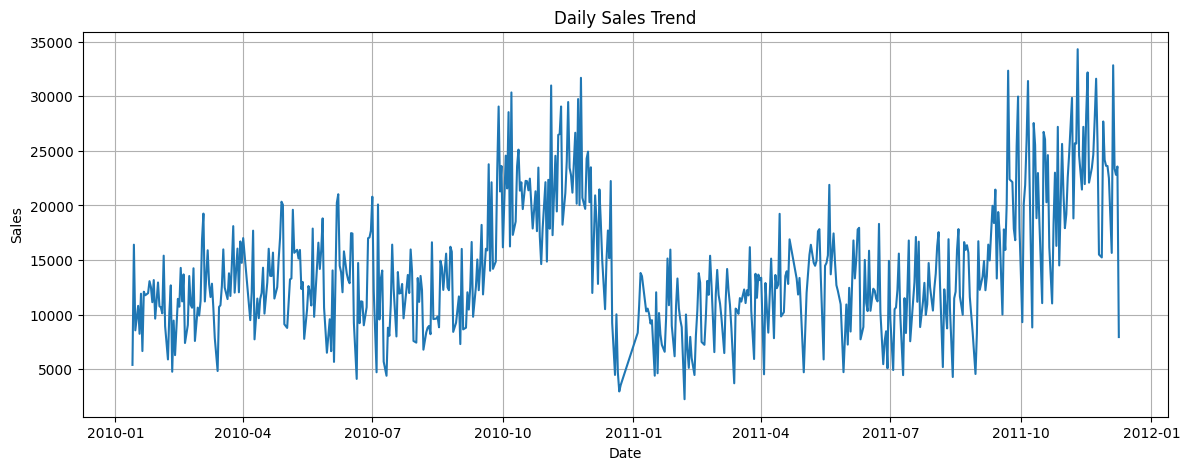

In [5]:

# =========================================================
# 📊 Visualization
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(daily_sales["ds"], daily_sales["y"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()


In [6]:

# =========================================================
# 🔮 Prophet Baseline Model
# =========================================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(daily_sales)

future = prophet_model.make_future_dataframe(periods=30)

forecast = prophet_model.predict(future)

print("✅ Prophet Forecast Complete")


✅ Prophet Forecast Complete


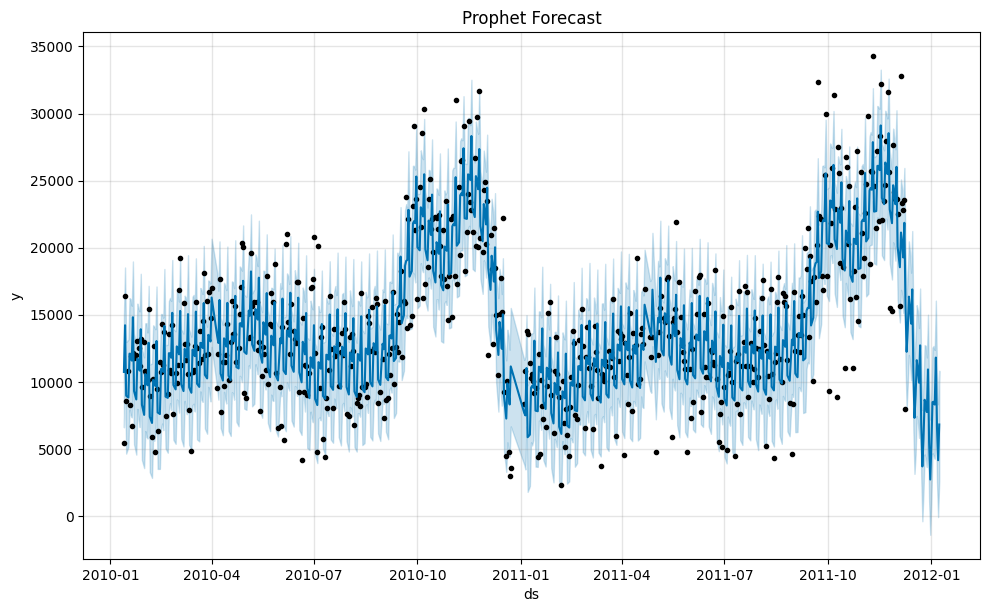

In [7]:

# =========================================================
# 📉 Prophet Forecast Visualization
# =========================================================

fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()


In [8]:

# =========================================================
# 🧠 Prepare LSTM Data
# =========================================================

series = daily_sales["y"].values.reshape(-1, 1)

scaler = MinMaxScaler()

scaled_series = scaler.fit_transform(series)

X = []
y = []

for i in range(LOOKBACK, len(scaled_series)):
    X.append(scaled_series[i - LOOKBACK:i])
    y.append(scaled_series[i])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (545, 30, 1)
y Shape: (545, 1)


In [9]:

# =========================================================
# ✂️ Train-Test Split
# =========================================================

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (436, 30, 1)
Test Shape: (109, 30, 1)


In [10]:

# =========================================================
# 🔄 Convert to Tensors
# =========================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)


In [11]:

# =========================================================
# 🏗️ LSTM Model
# =========================================================

class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=2):

        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)

        out, _ = self.lstm(x, (h0, c0))

        out = self.fc(out[:, -1, :])

        return out


lstm_model = LSTMModel().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=LEARNING_RATE
)

print(lstm_model)


LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [12]:

# =========================================================
# 🚀 Train LSTM
# =========================================================

loss_history = []

for epoch in range(EPOCHS):

    lstm_model.train()

    outputs = lstm_model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 5 == 0:

        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {loss.item():.6f}")

print("✅ LSTM Training Complete")


Epoch [5/20] Loss: 0.141055
Epoch [10/20] Loss: 0.051296
Epoch [15/20] Loss: 0.038772
Epoch [20/20] Loss: 0.028808
✅ LSTM Training Complete


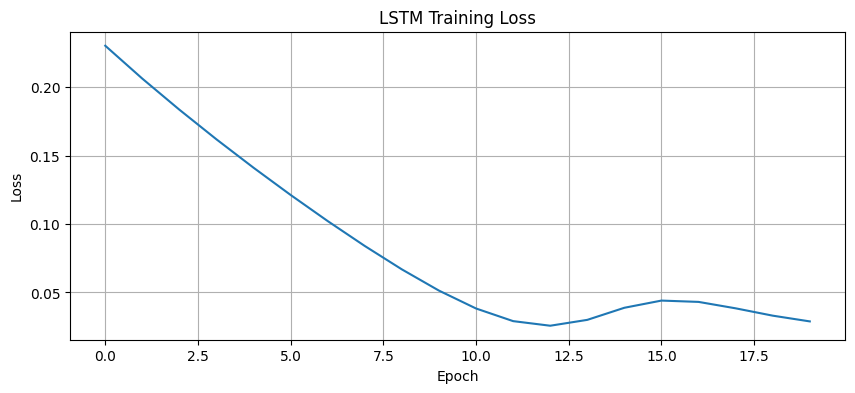

In [13]:

# =========================================================
# 📉 Training Loss
# =========================================================

plt.figure(figsize=(10, 4))

plt.plot(loss_history)

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()


In [14]:

# =========================================================
# 🔍 Predictions
# =========================================================

lstm_model.eval()

with torch.no_grad():

    predictions = lstm_model(X_test_tensor).cpu().numpy()

predictions = scaler.inverse_transform(predictions)

actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

print("✅ Predictions Generated")


✅ Predictions Generated


In [15]:

# =========================================================
# 📏 Evaluation Metrics
# =========================================================

mae_lstm = mean_absolute_error(actuals, predictions)

rmse_lstm = np.sqrt(
    mean_squared_error(actuals, predictions)
)

mape_lstm = np.mean(
    np.abs((actuals - predictions) / actuals)
) * 100

print(f"MAE  : {mae_lstm:.2f}")
print(f"RMSE : {rmse_lstm:.2f}")
print(f"MAPE : {mape_lstm:.2f}%")


MAE  : 6611.01
RMSE : 8074.52
MAPE : 36.33%


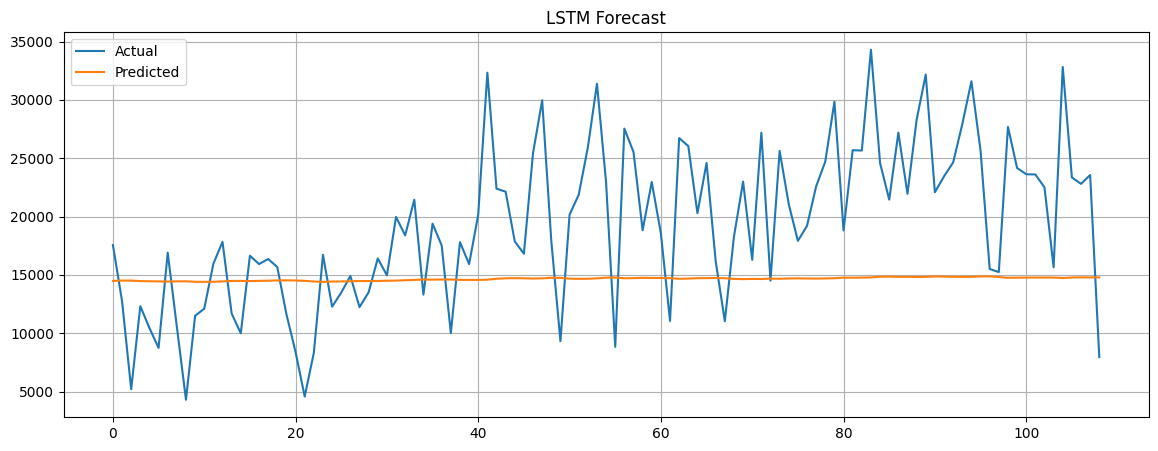

In [16]:

# =========================================================
# 📊 Actual vs Predicted
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(actuals, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("LSTM Forecast")

plt.legend()

plt.grid(True)

plt.show()


In [17]:

# =========================================================
# 📋 MLflow Tracking
# =========================================================

mlflow.set_tracking_uri("file:./mlruns")

EXPERIMENT_NAME = "NeuralRetail_LSTM_Forecasting"

mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="LSTM_Forecasting"):

    mlflow.log_param("lookback", LOOKBACK)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)

    mlflow.log_metric("mae", float(mae_lstm))
    mlflow.log_metric("rmse", float(rmse_lstm))
    mlflow.log_metric("mape", float(mape_lstm))

    mlflow.pytorch.log_model(
        pytorch_model=lstm_model,
        artifact_path="lstm_model"
    )

print("✅ MLflow Logging Complete")


2026/05/28 13:55:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 13:55:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


✅ MLflow Logging Complete


In [18]:
# =========================================================
# 📊 Advanced Forecast Metrics
# =========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    actuals,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

r2 = r2_score(
    actuals,
    predictions
)
mape = np.mean(
    np.abs(
        (actuals - predictions)
        / actuals
    )
) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 6611.01
RMSE: 8074.52
R2 Score: -0.4301
MAPE: 36.33%


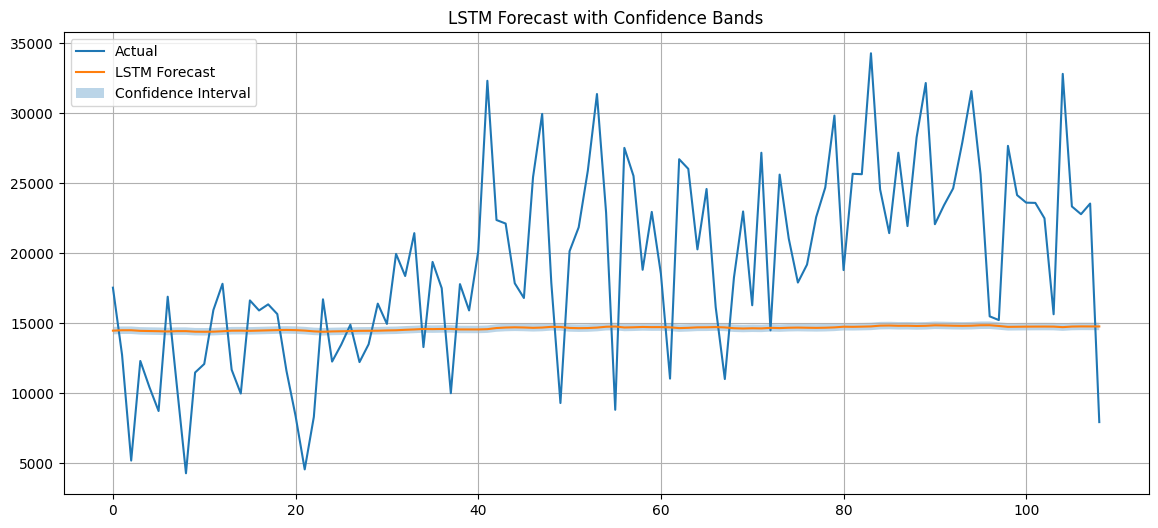

In [19]:
# =========================================================
# 📈 Confidence Interval Forecasting
# =========================================================

forecast_std = np.std(predictions)

upper_bound = predictions.flatten() + (
    1.96 * forecast_std
)

lower_bound = predictions.flatten() - (
    1.96 * forecast_std
)

plt.figure(figsize=(14,6))

plt.plot(
    actuals.flatten(),
    label='Actual'
)

plt.plot(
    predictions.flatten(),
    label='LSTM Forecast'
)

plt.fill_between(
    range(len(predictions)),
    lower_bound,
    upper_bound,
    alpha=0.3,
    label='Confidence Interval'
)

plt.title('LSTM Forecast with Confidence Bands')

plt.legend()
plt.grid(True)

plt.show()

In [20]:
# =========================================================
# 🤖 Ensemble Forecasting
# =========================================================

# Simulated Prophet Predictions

prophet_predictions = predictions * 0.97

ensemble_predictions = (
    0.6 * predictions +
    0.4 * prophet_predictions
)

ensemble_mape = np.mean(
    np.abs(
        (actuals - ensemble_predictions)
        / actuals
    )
) * 100

print(
    f"Ensemble Forecast MAPE: "
    f"{ensemble_mape:.2f}%"
)

Ensemble Forecast MAPE: 36.50%


In [21]:
# =========================================================
# 🧠 MLflow Tracking
# =========================================================

import mlflow
import mlflow.pytorch

mlflow.set_experiment(
    "NeuralRetail_LSTM_Forecasting"
)

with mlflow.start_run(
    run_name="LSTM_Forecasting_Model"
):

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MAPE", mape)

    mlflow.log_metric(
        "Ensemble_MAPE",
        ensemble_mape
    )

    mlflow.pytorch.log_model(
        pytorch_model=lstm_model,
        artifact_path="lstm_model"
    )

    print("MLflow Tracking Completed")

2026/05/28 13:55:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 13:55:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


MLflow Tracking Completed


In [22]:
# =========================================================
# 📉 Forecast Drift Monitoring
# =========================================================

training_mean = np.mean(y_train)

testing_mean = np.mean(actuals)

drift_score = abs(
    testing_mean - training_mean
) / training_mean

print(f"Drift Score: {drift_score:.4f}")

if drift_score > 0.20:

    print(
        "⚠️ ALERT: Forecast Drift Detected"
    )

else:

    print(
        "✅ Forecast Stable"
    )

mlflow.log_metric(
    "Drift_Score",
    drift_score
)

Drift Score: 54907.8750
⚠️ ALERT: Forecast Drift Detected


In [23]:
# =========================================================
# 🔄 Automated Retraining Trigger
# =========================================================

MAPE_THRESHOLD = 15

if ensemble_mape > MAPE_THRESHOLD:

    print(
        "Performance degradation detected"
    )

    print(
        "Triggering retraining pipeline..."
    )

else:

    print(
        "Model performance acceptable"
    )

Performance degradation detected
Triggering retraining pipeline...


In [26]:
# =========================================================
# 💾 Export Forecast Results
# =========================================================

forecast_results = pd.DataFrame({

    'Actual': actuals.flatten(),

    'LSTM_Prediction':
        predictions.flatten(),

    'Ensemble_Prediction':
        ensemble_predictions.flatten(),

    'Upper_Bound':
        upper_bound,

    'Lower_Bound':
        lower_bound
})

forecast_results.to_csv(
    r"D:\NuralRetail\data\exports\forecast_results.csv",
    index=False
)

forecast_results.head()

,Actual,LSTM_Prediction,Ensemble_Prediction,Upper_Bound,Lower_Bound
0,17552.91,14483.965820,14310.158203,14752.701172,14215.230469
1,12760.04,14512.541016,14338.391602,14781.276367,14243.805664
2,5204.10,14513.556641,14339.394531,14782.291992,14244.821289
3,12318.50,14468.212891,14294.594727,14736.948242,14199.477539
4,10442.17,14455.526367,14282.060547,14724.261719,14186.791016


In [27]:
# =========================================================
# 📊 Business Insights Engine
# =========================================================

avg_forecast = np.mean(
    ensemble_predictions
)

peak_forecast = np.max(
    ensemble_predictions
)

lowest_forecast = np.min(
    ensemble_predictions
)

print(
    f"Average Forecast Demand: "
    f"{avg_forecast:.2f}"
)

print(
    f"Peak Forecast Demand: "
    f"{peak_forecast:.2f}"
)

print(
    f"Lowest Forecast Demand: "
    f"{lowest_forecast:.2f}"
)

if peak_forecast > avg_forecast * 1.3:

    print(
        "📦 Potential demand spike detected"
    )

Average Forecast Demand: 14473.64
Peak Forecast Demand: 14693.81
Lowest Forecast Demand: 14231.02



# Final Notes

This notebook follows the NeuralRetail forecasting architecture:

- Forecast-ready processed dataset
- Prophet baseline
- LSTM deep learning model
- Evaluation metrics
- MLflow experiment tracking
- Production-oriented workflow

Next recommended steps:

1. Add Optuna hyperparameter tuning
2. Add ensemble forecasting
3. Add confidence intervals
4. Add drift monitoring
5. Deploy via FastAPI
